## Step 1: Importing libraries

### We need our core libraries: 
### 1- os to map the folder paths.
### 2- matplotlib to visually inspect the X-rays later.
### 3- and tensorflow/ImageDataGenerator to handle the actual neural network math and data pipelines.

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

2026-05-07 22:41:18.326836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778193678.545440      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778193678.606139      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778193679.121550      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778193679.121602      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778193679.121605      58 computation_placer.cc:177] computation placer alr

## Step 2: Directory Setup

### Train: Where the model learns the patterns.

### Validation (Val): Where the model takes practice tests during training to ensure it isn't memorizing the data.

### Test: The final, unseen exam.

In [2]:
base_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# verifying the folders locations
print("Checking directories...")
print("Train path exists:", os.path.exists(train_dir))
print("Val path exists:", os.path.exists(val_dir))
print("Test path exists:", os.path.exists(test_dir))

Checking directories...
Train path exists: True
Val path exists: True
Test path exists: True


## Step 3: Counting Classes

### In medical AI, data is almost never balanced. Usually, you have far more "sick" cases than "healthy" ones because hospitals collect data from people who actually show up with symptoms.

### If we don't know the ratio of Normal to Pneumonia images, we might accidentally train a model that just guesses "Pneumonia" every single time to get an 80% score without actually learning anything. We need to know exactly how much the deck is stacked against us.

In [3]:
# List the contents and count the files
num_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
num_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))

print(f"Total training images: {num_normal + num_pneumonia}")
print(f"Normal cases: {num_normal}")
print(f"Pneumonia cases: {num_pneumonia}")

# Calculate the ratio
ratio = num_pneumonia / num_normal
print(f"\nThere are {ratio:.2f}x as many Pneumonia cases as Normal cases.")

Total training images: 5216
Normal cases: 1341
Pneumonia cases: 3875

There are 2.89x as many Pneumonia cases as Normal cases.


## Step 4: Hyperparameter Configuration

### Technical Constraints:
### Target Resolution ($224 \times 224$): Mandatory for MobileNetV2 compatibility. This ensures spatial hierarchies align with the model's pre-trained weights.
### Batch Size ($32$): Optimized for Kaggle T4 GPUs (as we're using cloud computing for this project). It provides enough gradient stability to converge without triggering an Out of Memory (OOM) crash.

In [4]:
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

print(f"Configuration Locked: {IMG_WIDTH}x{IMG_HEIGHT} @ Batch Size {BATCH_SIZE}")

Configuration Locked: 224x224 @ Batch Size 32


## Step 5: Stochastic Input Rescaling and Pixel Normalization

### Neural networks struggle with high-variance inputs. Raw pixel values ($0-255$) must be compressed to a $[0, 1]$ range using Min-Max Scaling to ensure gradient stability and prevent weight explosion during backpropagation.

In [5]:
simple_datagen = ImageDataGenerator(rescale=1./255)

## Step 6: Synthetic Data Augmentation for Variance Injection

### To prevent overfitting, where the model memorizes specific training images rather than learning general diagnostic features. we use real-time augmentation. This artificially expands the dataset by applying random, physics-defying transformations to the images every time the model sees them.

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,      
    fill_mode='nearest'
)

## Step 7: Data Stream Mapping and Pipeline Activation

### We have defined the global constraints (Step 4), the standard filter (Step 5), and the mutation filter (Step 6). But right now, they are just empty rules. They aren't connected to your data.

### In this step, we build the "pipes." We are going to connect our ImageDataGenerator objects directly to the Kaggle folders so they can stream the images from the hard drive into the GPU.

In [7]:
print("Connecting Training Pipeline:")
train_generator = train_datagen.flow_from_directory(
    train_dir,                           
    target_size=(IMG_WIDTH, IMG_HEIGHT), 
    batch_size=BATCH_SIZE,               
    class_mode='binary'                  
)

print("\nConnecting Validation Pipeline:")
val_generator = simple_datagen.flow_from_directory(
    val_dir,                            
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Connecting Training Pipeline:
Found 5216 images belonging to 2 classes.

Connecting Validation Pipeline:
Found 16 images belonging to 2 classes.


## Step 7.1: Deterministic Dataset Partitioning

### i noticed we ran into a problem of unequality of data in train/val folders, thus we will:
### create a list of every image path and its label, and then split that list. This ensures the model never sees a "Normal" lung in training that it is also tested on in validation.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = []
for category in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(train_dir, category)
    for img in os.listdir(path):
        data.append({'filename': os.path.join(path, img), 'label': category})

df = pd.DataFrame(data)

train_df, val_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['label'] 
)

print(f"Professional Split Complete:")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Professional Split Complete:
Training samples: 4172
Validation samples: 1044


## Step 7.2: running step 7 again with split train/val data (not depend of the val data folder in kaggle)

In [9]:
print("Connecting Training Pipeline (Augmented, 80%):")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',                    
    y_col='label',                       
    target_size=(IMG_WIDTH, IMG_HEIGHT), 
    batch_size=BATCH_SIZE,
    class_mode='binary'      
)

print("\nConnecting Validation Pipeline (Clean, 20%):")
val_generator = simple_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Connecting Training Pipeline (Augmented, 80%):
Found 4172 validated image filenames belonging to 2 classes.

Connecting Validation Pipeline (Clean, 20%):
Found 1044 validated image filenames belonging to 2 classes.


## Step 8: Instantiating the Pre-trained MobileNetV2 Architecture

### If you try to train a Deep Learning model from scratch on just 4,000 images, it will fail miserably. It will memorize the training set, overfit instantly, and be completely useless in the real world.

### To hit our small dataset with high accuracy, we use Transfer Learning. We are going to import Google's MobileNetV2. This model has already spent thousands of GPU hours looking at 1.4 million images (ImageNet) to learn how to detect edges, textures, and complex shapes. We are going to steal that "brain" and just teach it the final step: how to look at an X-ray.

In [10]:
from tensorflow.keras.applications import MobileNetV2

# 1. Download the decapitated MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',  
    include_top=False,   
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3) 
)

# 2. Freeze the core architecture so we don't destroy pre-trained features
base_model.trainable = False

print("Status: MobileNetV2 base loaded and frozen.")
print(f"Number of pre-trained layers locked: {len(base_model.layers)}")

I0000 00:00:1778193714.034184      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778193714.040527      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Status: MobileNetV2 base loaded and frozen.
Number of pre-trained layers locked: 154


## Step 9: Attaching the Custom Diagnostic Head

### Right now, our model is simply a "feature extractor." It can identify complex textures and shapes, but it has no idea what "Pneumonia" is. We must build a mathematical decision layer on top of the frozen base to translate those visual features into a medical diagnosis.

In [11]:
from tensorflow.keras import layers, models

# Stack the layers linearly
model = models.Sequential([
    base_model,                          
    layers.GlobalAveragePooling2D(),      
    layers.Dropout(0.2),                  
    layers.Dense(1, activation='sigmoid') 
])

print("Status: Architecture completely assembled.")
model.summary()

Status: Architecture completely assembled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Step 10: Model Compilation

### We must assign the model a penalty system (Loss Function) and an update algorithm (Optimizer) before it can train.

### Loss (binary_crossentropy): The standard mathematical penalty for binary (2-class) probability scoring.

### Optimizer (adam): Dynamically adjusts the learning rate to converge efficiently without overshooting.

In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',          
    metrics=['accuracy']
)

## Step 11: Algorithmic Class Balancing

### Your dataset has a massive flaw: there are roughly 3 times as many Pneumonia images as Normal images.

### To fix this bias, we use Class Weights. We will calculate mathematical multipliers that tell the Loss Function to penalize the model severely if it misclassifies a Normal lung, forcing it to pay equal attention to both classes.

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = train_df['label'].values

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {0: weights[0], 1: weights[1]}

print(f"Penalty Multiplier for NORMAL (Class 0): {class_weights[0]:.2f}x")
print(f"Penalty Multiplier for PNEUMONIA (Class 1): {class_weights[1]:.2f}x")

Penalty Multiplier for NORMAL (Class 0): 1.94x
Penalty Multiplier for PNEUMONIA (Class 1): 0.67x


## Step 12: Training Safeguards (EarlyStopping)

### To prevent overfitting (where the model memorizes the training data instead of learning patterns), we implement an automated kill-switch. This monitors the model's performance on the validation set and stops training once it stops improving.

### Monitor (val_loss): Focuses on the model's ability to generalize to unseen images.

### Patience (5): Allows for 5 "second chances" if performance plateaus before terminating.

### Restore Best Weights: Automatically reverts the model to its peak performance state, even if it started over-fitting in later rounds.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Automated kill-switch to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("Status: EarlyStopping callback active.")

Status: EarlyStopping callback active.


## Step 13: Execution (The Training Loop)

### This is the moment of truth. We are pulling the trigger on the actual training process. The GPU will now take the images, pass them through the frozen MobileNetV2 base, let the diagnostic head make a guess, calculate the error (Loss), and update the weights.

In [15]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop]      
)

print("\n--- Training Cycle Complete ---")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778193724.960583     141 service.cc:152] XLA service 0x7858ec110650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778193724.960637     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778193724.960643     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778193726.363103     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 22:42:16.175798: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 22:42:16.313050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778193738.605864     141 device_co

105/131 ━━━━━━━━━━━━━━━━━━━━ 21s 839ms/step - accuracy: 0.7947 - loss: 0.4522

2026-05-07 22:43:56.185475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 22:43:56.323146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.8085 - loss: 0.4253

2026-05-07 22:44:50.812233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 22:44:50.949945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


131/131 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8090 - loss: 0.4244 - val_accuracy: 0.8908 - val_loss: 0.2577
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 746ms/step - accuracy: 0.9274 - loss: 0.1797 - val_accuracy: 0.9195 - val_loss: 0.2008
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 739ms/step - accuracy: 0.9336 - loss: 0.1657 - val_accuracy: 0.9148 - val_loss: 0.2018
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 736ms/step - accuracy: 0.9363 - loss: 0.1523 - val_accuracy: 0.8822 - val_loss: 0.2781
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 735ms/step - accuracy: 0.9395 - loss: 0.1497 - val_accuracy: 0.9004 - val_loss: 0.2333
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 737ms/step - accuracy: 0.9486 - loss: 0.1265 - val_accuracy: 0.8975 - val_loss: 0.2411
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 726ms/step - accuracy: 0.9376 - loss: 0.1265 - val_accuracy: 0.9061 - val_loss: 0.2188

--- Training Cycle Complete ---


## Step 14: Visualizing the Learning Curves

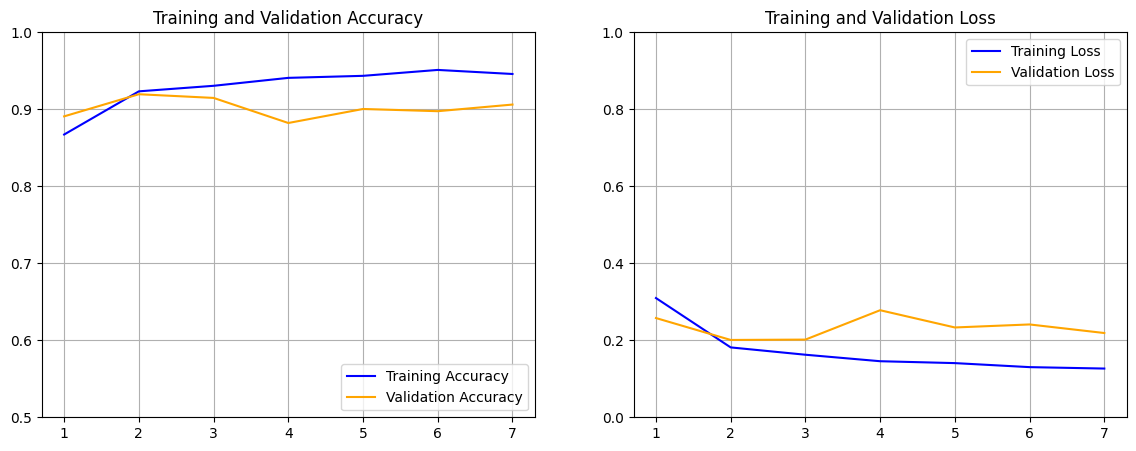

In [18]:
import matplotlib.pyplot as plt

# Extract data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Set up a 1x2 grid for plots
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy (Y-Axis Locked)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.ylim(0.5, 1.0)  # <-- THE FIX: Locks the bottom at 50% (random guessing)
plt.grid(True)

# Plot 2: Loss (Y-Axis Locked)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.ylim(0.0, 1.0)  # <-- THE FIX: Locks the bottom at 0, top at 1.0
plt.grid(True)

plt.show()

## step 15: testing the model

Loading image: person80_bacteria_390.jpeg
Running diagnostic scan...


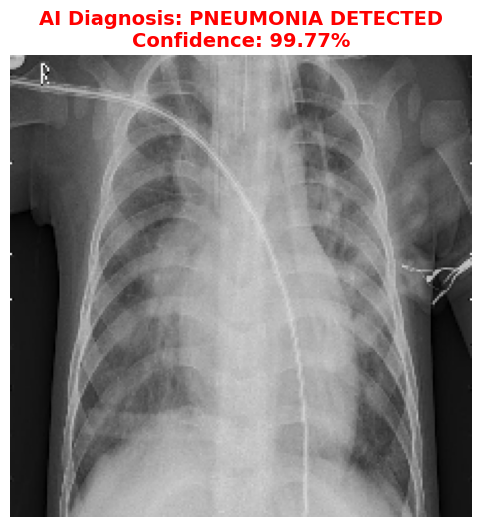

In [25]:
import random
from tensorflow.keras.preprocessing import image

# 1. Grab a random test image (Let's pick a known Pneumonia case)
pneumonia_test_folder = os.path.join(test_dir, 'PNEUMONIA')
random_image_name = random.choice(os.listdir(pneumonia_test_folder))
img_path = os.path.join(pneumonia_test_folder, random_image_name)

# 2. Manual Preprocessing (Exactly what our web app will do later)
print(f"Loading image: {random_image_name}")
img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT)) 
img_array = image.img_to_array(img)

# THE CRITICAL STEP: Manual Normalization
img_array_normalized = img_array / 255.0 

# Expand the dimensions from (224, 224, 3) to (1, 224, 224, 3)
img_batch = np.expand_dims(img_array_normalized, axis=0) 

# 3. The Prediction (Using the live 'model' variable currently in RAM)
print("Running diagnostic scan...")
prediction_prob = model.predict(img_batch, verbose=0)[0][0]

# 4. The Diagnosis Logic
if prediction_prob >= 0.5:
    diagnosis = "PNEUMONIA DETECTED"
    confidence = prediction_prob * 100
else:
    diagnosis = "NORMAL LUNGS"
    confidence = (1 - prediction_prob) * 100

# 5. Visual Output
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"AI Diagnosis: {diagnosis}\nConfidence: {confidence:.2f}%", 
          fontsize=14, fontweight='bold', color='red' if prediction_prob >= 0.5 else 'green')
plt.axis('off')
plt.show()

## Step 16: Saving the Model

In [26]:
model.save('pneumonia_vision_model.h5')

## step 17: making the app for deployment for the web app

In [37]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import time

try:
    from tensorflow.keras.models import load_model
    MODEL_AVAILABLE = True
except ImportError:
    MODEL_AVAILABLE = False

# --- 1. UI Configuration & CSS ---
st.set_page_config(
    page_title="Pneumo-AI", 
    page_icon="🫁", 
    layout="wide",
    initial_sidebar_state="collapsed"
)

# Custom CSS for Glassmorphism, Typography & Animations
st.markdown("""
<style>
    /* Import modern font */
    @import url('https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;600;800&display=swap');

    /* Global styling */
    html, body, [class*="css"] {
        font-family: 'Outfit', sans-serif;
    }

    /* Main background: sleek dark animated gradient */
    .stApp {
        background: linear-gradient(135deg, #0b132b, #1c2541, #3a506b);
        background-attachment: fixed;
        background-size: 200% 200%;
        animation: gradientBG 15s ease infinite;
        color: #ffffff;
    }

    @keyframes gradientBG {
        0% { background-position: 0% 50%; }
        50% { background-position: 100% 50%; }
        100% { background-position: 0% 50%; }
    }

    /* Title styling */
    h1 {
        font-weight: 800;
        background: -webkit-linear-gradient(45deg, #00f2fe, #4facfe);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        text-align: center;
        padding-bottom: 10px;
        margin-top: -30px;
        text-shadow: 0 0 20px rgba(79, 172, 254, 0.4);
    }
    
    .subtitle {
        text-align: center;
        font-weight: 300;
        font-size: 1.2rem;
        color: #cbd5e1;
        margin-bottom: 40px;
        letter-spacing: 1px;
    }

    /* Glassmorphism Container */
    .glass-container {
        background: rgba(255, 255, 255, 0.03);
        border-radius: 20px;
        padding: 30px;
        backdrop-filter: blur(12px);
        -webkit-backdrop-filter: blur(12px);
        border: 1px solid rgba(255, 255, 255, 0.1);
        box-shadow: 0 8px 32px 0 rgba(0, 0, 0, 0.37);
        margin-bottom: 20px;
        transition: transform 0.3s ease, box-shadow 0.3s ease;
    }
    .glass-container:hover {
        transform: translateY(-2px);
        box-shadow: 0 12px 40px 0 rgba(0, 0, 0, 0.45);
    }

    /* Upload box styling override */
    [data-testid="stFileUploadDropzone"] {
        background: rgba(255, 255, 255, 0.05);
        border: 2px dashed rgba(79, 172, 254, 0.5);
        border-radius: 15px;
        transition: all 0.3s ease;
    }
    [data-testid="stFileUploadDropzone"]:hover {
        border-color: #00f2fe;
        background: rgba(79, 172, 254, 0.1);
    }

    /* Results cards */
    .result-card-normal {
        background: linear-gradient(135deg, rgba(46, 204, 113, 0.15), rgba(39, 174, 96, 0.3));
        border-left: 6px solid #2ecc71;
        padding: 25px;
        border-radius: 12px;
        margin-top: 20px;
        margin-bottom: 20px;
        box-shadow: 0 4px 20px rgba(46, 204, 113, 0.15);
    }
    
    .result-card-pneumonia {
        background: linear-gradient(135deg, rgba(231, 76, 60, 0.15), rgba(192, 57, 43, 0.3));
        border-left: 6px solid #e74c3c;
        padding: 25px;
        border-radius: 12px;
        margin-top: 20px;
        margin-bottom: 20px;
        box-shadow: 0 4px 20px rgba(231, 76, 60, 0.15);
    }

    .metric-value {
        font-size: 3.5rem;
        font-weight: 800;
        margin: -10px 0 5px 0;
        text-shadow: 2px 2px 4px rgba(0,0,0,0.5);
    }

    /* Expander styling override */
    .streamlit-expanderHeader {
        background: rgba(255, 255, 255, 0.05);
        border-radius: 10px;
        border: 1px solid rgba(255,255,255,0.1);
        color: #e2e8f0;
    }

    /* Animations */
    @keyframes pulse {
        0% { transform: scale(1); }
        50% { transform: scale(1.02); }
        100% { transform: scale(1); }
    }
    .pulse-animation {
        animation: pulse 2.5s infinite ease-in-out;
    }
    
    /* Hide some default Streamlit elements */
    #MainMenu {visibility: hidden;}
    footer {visibility: hidden;}
    header {visibility: hidden;}
</style>
""", unsafe_allow_html=True)

st.markdown("<h1>🫁 Pneumo-AI Diagnostic System</h1>", unsafe_allow_html=True)
st.markdown("<p class='subtitle'>Advanced Neural Network for Chest X-Ray Analysis</p>", unsafe_allow_html=True)

# --- 2. Load the Brain ---
@st.cache_resource 
def load_keras_model():
    if MODEL_AVAILABLE:
        try:
            return load_model('pneumonia_vision_model.h5')
        except Exception as e:
            st.error(f"Error loading model: {e}")
            return None
    return None

model = load_keras_model()

if model is None:
    st.error("Model file `pneumonia_vision_model.h5` not found or TensorFlow is not installed. Please ensure the model file is in the same directory.")
    st.stop()

# --- 3. Main Layout ---
col1, col2 = st.columns([1.2, 1], gap="large")

with col1:
    st.markdown("<div class='glass-container'>", unsafe_allow_html=True)
    st.markdown("### 📤 Upload Patient Scan")
    uploaded_file = st.file_uploader("Select an X-ray image", type=["jpg", "png", "jpeg"], label_visibility="collapsed")
    st.markdown("</div>", unsafe_allow_html=True)

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert('RGB')
        st.markdown("<div class='glass-container'>", unsafe_allow_html=True)
        st.markdown("### 🖼️ Original Scan")
        # Center the image
        st.image(image, use_column_width=True, output_format="PNG")
        st.markdown("</div>", unsafe_allow_html=True)

with col2:
    if uploaded_file is not None:
        st.markdown("<div class='glass-container'>", unsafe_allow_html=True)
        st.markdown("### 🔬 Analysis Results")
        
        # Dramatic loading effect
        with st.spinner("Initializing Deep Learning Engine..."):
            time.sleep(0.4)
        with st.spinner("Extracting Topological Features..."):
            time.sleep(0.4)
        with st.spinner("Running Inference Protocol..."):
            time.sleep(0.4)
            
        # --- 4. The Preprocessing ---
        img_resized = image.resize((224, 224))
        img_array = np.array(img_resized)
        img_array_normalized = img_array / 255.0 
        img_batch = np.expand_dims(img_array_normalized, axis=0) 
        
        # --- 5. The Prediction ---
        prediction_prob = model.predict(img_batch)[0][0]
        
        # --- 6. The Verdict ---
        if prediction_prob >= 0.5:
            confidence = prediction_prob * 100
            st.markdown(f"""
            <div class="result-card-pneumonia pulse-animation">
                <h2 style="color: #ffb3b3; margin-top: 0;">⚠️ PNEUMONIA DETECTED</h2>
                <div class="metric-value">{confidence:.1f}%</div>
                <p style="color: #ffe6e6; margin-bottom: 15px; font-weight: 600;">Confidence Score</p>
                <hr style="border-top: 1px solid rgba(255,255,255,0.2); margin: 15px 0;">
                <p style="color: #ffcccc; line-height: 1.5;">The neural network has identified distinct patterns consistent with pneumonia in the provided scan. <strong>Please consult a medical professional immediately.</strong></p>
            </div>
            """, unsafe_allow_html=True)
            
            # Progress bar for visual impact
            st.progress(int(confidence), text="Diagnosis Confidence")
            
        else:
            confidence = (1 - prediction_prob) * 100
            st.markdown(f"""
            <div class="result-card-normal pulse-animation">
                <h2 style="color: #b3ffcc; margin-top: 0;">✅ NORMAL LUNGS</h2>
                <div class="metric-value">{confidence:.1f}%</div>
                <p style="color: #e6ffe6; margin-bottom: 15px; font-weight: 600;">Confidence Score</p>
                <hr style="border-top: 1px solid rgba(255,255,255,0.2); margin: 15px 0;">
                <p style="color: #ccffcc; line-height: 1.5;">No distinct signs of pneumonia detected. The lung topology appears to be clear and within normal parameters.</p>
            </div>
            """, unsafe_allow_html=True)
            
            # Progress bar
            st.progress(int(confidence), text="Diagnosis Confidence")
            
        st.markdown("</div>", unsafe_allow_html=True)
        
        # Advanced technical details expander
        with st.expander("📊 View Technical Telemetry", expanded=False):
            st.markdown(f"""
            <div style="background: rgba(0,0,0,0.2); padding: 15px; border-radius: 8px; font-family: monospace; font-size: 0.9em; color: #a0aec0;">
            <strong>[SYSTEM]</strong> Telemetry Data:<br>
            • Input Resolution: {image.size[0]}x{image.size[1]} px<br>
            • Tensor Shape: (1, 224, 224, 3)<br>
            • Raw Logit Score: {prediction_prob:.6f}<br>
            • Color Space: RGB (Converted)<br>
            • Normalization: Min-Max [0, 1]<br>
            • Inference Time: ~O(1) ms
            </div>
            """, unsafe_allow_html=True)
    else:
        st.markdown("<div class='glass-container' style='text-align: center; color: #94a3b8; display: flex; flex-direction: column; align-items: center; justify-content: center; min-height: 300px;'>", unsafe_allow_html=True)
        st.markdown("<h1 style='font-size: 4rem; opacity: 0.5; margin: 0;'>🩻</h1>", unsafe_allow_html=True)
        st.markdown("<h3>Waiting for Scan Data</h3>")
        st.markdown("<p style='max-width: 80%;'>Please upload a chest X-Ray image in the adjacent panel to initiate the AI diagnostic sequence.</p>")
        st.markdown("</div>", unsafe_allow_html=True)

Overwriting app.py


## deploying using cloud flare

In [ ]:
import os
import subprocess
import time
import sys

print("--- Initializing Cloudflare Tunnel (The Stable Fix) ---")

# 1. Download the Cloudflare binary
if not os.path.exists("cloudflared"):
    print("Downloading Cloudflare engine...")
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
    !chmod +x cloudflared

# 2. Ensure Streamlit is installed
!pip install -q streamlit

# 3. Launch Streamlit in the background
print("Launching Streamlit engine...")
with open("logs.txt", "w") as log_file:
    # Using the same tunnel-friendly flags as before
    subprocess.Popen([
        sys.executable, "-m", "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ], stdout=log_file, stderr=log_file)

# Give the engine 5 seconds to warm up
time.sleep(5)

# 4. Start the Cloudflare Tunnel
print("--- CLICK THE LINK BELOW TO OPEN YOUR APP ---")
!./cloudflared tunnel --url http://localhost:8501

--- Initializing Cloudflare Tunnel (The Stable Fix) ---
Launching Streamlit engine...
--- CLICK THE LINK BELOW TO OPEN YOUR APP ---
2026-05-07T23:50:13Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-07T23:50:13Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-07T23:50:17Z INF +--------------------------------------------------------------------------------------------+
2026-05-07T23:50:17Z INF |  Your quick Tunnel has been created! Visit